<a href="https://colab.research.google.com/github/Fernandateireis/projecoes_cbae_ence/blob/main/analises_descritivas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capítulo 6 — Reprodução das tabelas e figuras

Este notebook reproduz todas as tabelas (6 a 24) e figuras (3 a 12) do Capítulo 6 (Análises descritivas).

**Como usar:** rode as células em ordem. A Parte 0 carrega tudo o que as demais precisam. Cada tabela é exibida e guardada; a última célula exporta todas para `capitulo6/capitulo6_tabelas.xlsx` no Drive, e cada figura é salva como PNG na mesma pasta, sem título embutido (a legenda fica no Word, no padrão ABNT).

**Arquivos usados (pasta `Colab Notebooks/` do Drive):** `pnadc_2014_2025.parquet`, `familias_COD_ancoras_final.csv` e, na seção de plataformização, `pnad/pnadc_plataformizacao_2022T4.parquet` e `pnad/pnadc_plataformizacao_2024T3.parquet`.

## Parte 0 — Configuração e base

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
drive.mount('/content/drive')

pasta = '/content/drive/MyDrive/Colab Notebooks/'
OUT = pasta + 'capitulo6/'
os.makedirs(OUT, exist_ok=True)

TABELAS = {}                     # guarda todas as tabelas para exportar no final

def guarda(nome, tab, casas=1):
    """Exibe a tabela arredondada e guarda para exportação."""
    TABELAS[nome] = tab
    display(tab.round(casas) if hasattr(tab, 'round') else tab)

def salva_fig(nome):
    plt.savefig(OUT + nome + '.png', dpi=200, bbox_inches='tight')
    plt.show()

def eixo_anos(ax, anos, pandemia=True):
    ax.set_xticks(list(anos))
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)
    if pandemia:
        ax.axvspan(2019.5, 2021.5, color='grey', alpha=0.12)

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
print('✓ configuração pronta | saídas em', OUT)

Mounted at /content/drive
✓ configuração pronta | saídas em /content/drive/MyDrive/Colab Notebooks/capitulo6/


In [2]:
# ---------- Base PNAD Contínua 2014–2025 ----------
df = pd.read_parquet(pasta + 'pnadc_2014_2025.parquet')
df['Ano'] = df['Ano'].astype(int)
df['V2007'] = df['V2007'].astype(str).replace({'Masculino': 'Homem', 'Feminino': 'Mulher'})
pop_ano = df.groupby('Ano')['V1032'].sum() / 1e6          # população (milhões)

# Crosswalk
cw = pd.read_csv(pasta + 'familias_COD_ancoras_final.csv', sep=';', dtype={'cod_familia': str})
cw['cod_familia'] = cw['cod_familia'].str.zfill(4)

# Ocupados + crosswalk + variáveis de perfil
oc = df[df['VD4002'] == 'Pessoas ocupadas'].copy()
oc['V4010'] = oc['V4010'].astype(str).str.zfill(4)
oc = oc.merge(cw[['cod_familia', 'nome_familia', 'ancora', 'nivel', 'circulo']],
              left_on='V4010', right_on='cod_familia', how='left')

oc['mulher'] = oc['V2007'] == 'Mulher'
raca = oc['V2010'].astype(str)
oc['negra'] = raca.isin(['Preta', 'Parda'])
oc['branca'] = raca == 'Branca'
oc['raca_neg'] = raca.replace({'Preta': 'Negra', 'Parda': 'Negra'})
vd = oc['VD4009'].astype(str).str.lower()
oc['formal_contrib'] = oc['VD4012'].astype(str) == 'Contribuinte'                    # contribui para a previdência
oc['formal_vinculo'] = vd.str.contains('com carteira') | vd.str.startswith('militar')  # carteira + militares/estatutários ("tipo RAIS")
oc['publico'] = vd.str.contains('setor público') | vd.str.startswith('militar')
oc['V2009'] = pd.to_numeric(oc['V2009'], errors='coerce')
oc['VD4016'] = pd.to_numeric(oc['VD4016'], errors='coerce')
oc['grupo'] = np.select(
    [oc.mulher & oc.negra, oc.mulher & oc.branca, ~oc.mulher & oc.negra, ~oc.mulher & oc.branca],
    ['Mulheres negras', 'Mulheres brancas', 'Homens negros', 'Homens brancos'], default='Outros')

ANOS = sorted(oc['Ano'].unique())
w = 'V1032'
def soma(d):              # milhões
    return d[w].sum() / 1e6
def pct(d, cond):         # % ponderado
    return 100 * d.loc[cond, w].sum() / d[w].sum()

print(f"Registros: {len(df):,} | ocupados: {len(oc):,} | sem âncora: {oc.ancora.isna().sum():,}")
print("Ocupados 2025 (mi):", round(soma(oc[oc.Ano == 2025]), 2))

Registros: 4,979,050 | ocupados: 2,137,544 | sem âncora: 1,034
Ocupados 2025 (mi): 102.98


## 6.1 O mercado de trabalho brasileiro, 2014–2025

### Figura 3 e Tabela 6 — Ocupados e indicadores selecionados

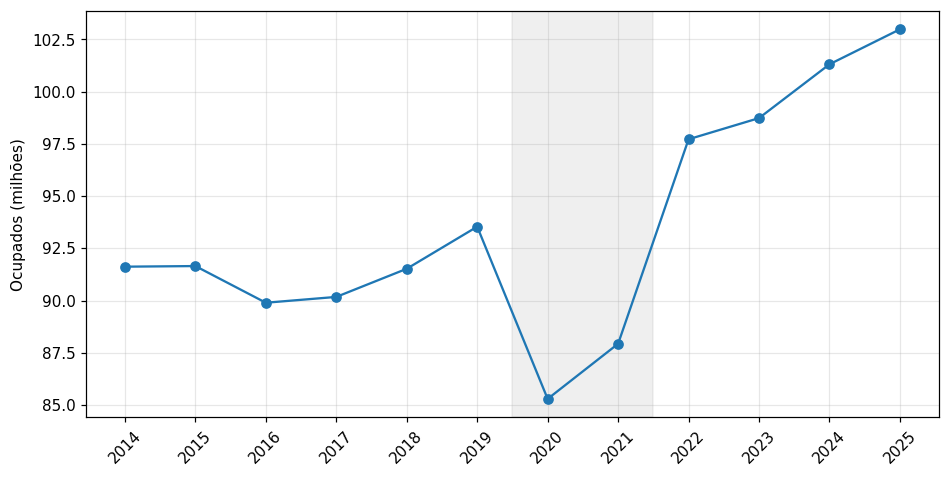

,2014,2019,2020,2025
Pessoas ocupadas (milhões),91.6,93.5,85.3,103.0
Mulheres ocupadas (milhões),38.5,40.1,35.7,44.8
Participação feminina na ocupação (%),42.0,42.9,41.9,43.5
Formais – contribuem para a previdência (milhões),59.6,58.9,55.8,67.5
Informais – não contribuem (milhões),32.0,34.6,29.5,35.5
Taxa de informalidade (%),34.9,37.0,34.6,34.4
"Vínculo formal – carteira, militares e estatutários (%)",51.9,47.6,49.5,48.5


População (milhões): {2014: 200.2, 2025: 212.7} | crescimento da população (%): 6.2 | crescimento da ocupação (%): 12.4


In [3]:
ocup_ano = oc.groupby('Ano')[w].sum() / 1e6

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(ocup_ano.index, ocup_ano.values, marker='o')
ax.set_ylabel('Ocupados (milhões)')
eixo_anos(ax, ANOS)
salva_fig('Figura_03_ocupados')

def indicadores_ano(d):
    return pd.Series({
        'Pessoas ocupadas (milhões)': soma(d),
        'Mulheres ocupadas (milhões)': soma(d[d.mulher]),
        'Participação feminina na ocupação (%)': pct(d, d.mulher),
        'Formais – contribuem para a previdência (milhões)': soma(d[d.formal_contrib]),
        'Informais – não contribuem (milhões)': soma(d[~d.formal_contrib]),
        'Taxa de informalidade (%)': pct(d, ~d.formal_contrib),
        'Vínculo formal – carteira, militares e estatutários (%)': pct(d, d.formal_vinculo),
    })

tab6 = pd.DataFrame({a: indicadores_ano(oc[oc.Ano == a]) for a in [2014, 2019, 2020, 2025]})
guarda('Tabela_06', tab6)

print("População (milhões):", pop_ano.loc[[2014, 2025]].round(1).to_dict(),
      "| crescimento da população (%):", round(100 * (pop_ano.loc[2025] / pop_ano.loc[2014] - 1), 1),
      "| crescimento da ocupação (%):", round(100 * (ocup_ano.loc[2025] / ocup_ano.loc[2014] - 1), 1))

### Figura 4 — Ocupados por sexo

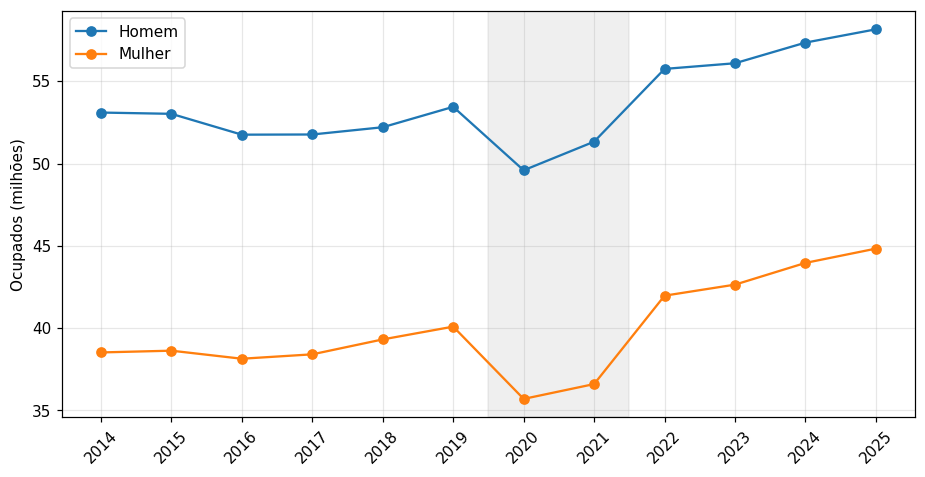

V2007,Homem,Mulher
Ano,,
2014,53.10,38.52
2015,53.02,38.63
2016,51.75,38.14
2017,51.76,38.41
2018,52.20,39.32
2019,53.44,40.09
2020,49.59,35.70
2021,51.33,36.60
2022,55.75,41.97


Variação 2014–2025 (%): {'Homem': 9.5, 'Mulher': 16.4}


In [4]:
tab_sexo = oc.groupby(['Ano', 'V2007'])[w].sum().unstack() / 1e6
fig, ax = plt.subplots(figsize=(10, 4.8))
for s in ['Homem', 'Mulher']:
    ax.plot(tab_sexo.index, tab_sexo[s], marker='o', label=s)
ax.set_ylabel('Ocupados (milhões)'); ax.legend()
eixo_anos(ax, ANOS)
salva_fig('Figura_04_sexo')
guarda('Fig04_dados_sexo', tab_sexo, 2)
print("Variação 2014–2025 (%):", (100 * (tab_sexo.loc[2025] / tab_sexo.loc[2014] - 1)).round(1).to_dict())

### Figura 5 — Ocupados por faixa etária

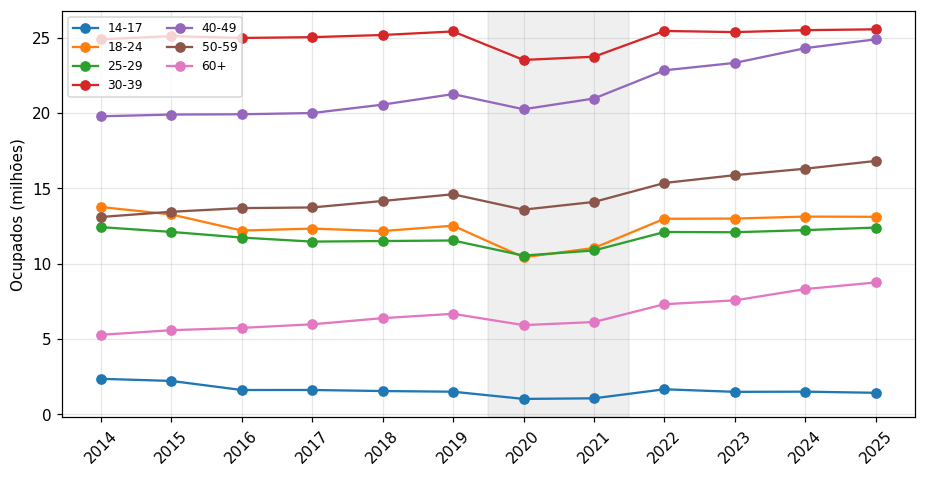

V2009,14-17,18-24,25-29,30-39,40-49,50-59,60+
Ano,,,,,,,
2014,2.36,13.76,12.43,24.90,19.79,13.10,5.28
2015,2.22,13.27,12.11,25.11,19.90,13.45,5.59
2016,1.62,12.20,11.74,24.99,19.92,13.69,5.74
2017,1.62,12.33,11.47,25.04,20.00,13.73,5.98
2018,1.55,12.17,11.51,25.18,20.56,14.17,6.39
2019,1.50,12.52,11.54,25.42,21.26,14.61,6.67
2020,1.03,10.43,10.54,23.53,20.25,13.59,5.92
2021,1.06,11.04,10.88,23.74,20.97,14.10,6.13
2022,1.67,12.98,12.11,25.45,22.84,15.36,7.31


In [30]:
faixa = pd.cut(oc['V2009'], bins=[13, 17, 24, 29, 39, 49, 59, 200],
               labels=['14-17', '18-24', '25-29', '30-39', '40-49', '50-59', '60+'])
tab_idade = oc.groupby(['Ano', faixa], observed=True)[w].sum().unstack() / 1e6
fig, ax = plt.subplots(figsize=(10, 4.8))
for c in tab_idade.columns:
    ax.plot(tab_idade.index, tab_idade[c], marker='o', label=c)
ax.set_ylabel('Ocupados (milhões)'); ax.legend(fontsize=8, ncol=2)
eixo_anos(ax, ANOS)
salva_fig('Figura_05_idade')
guarda('Fig05_dados_idade', tab_idade, 2)

### Figura 6 — Ocupados por anos de estudo

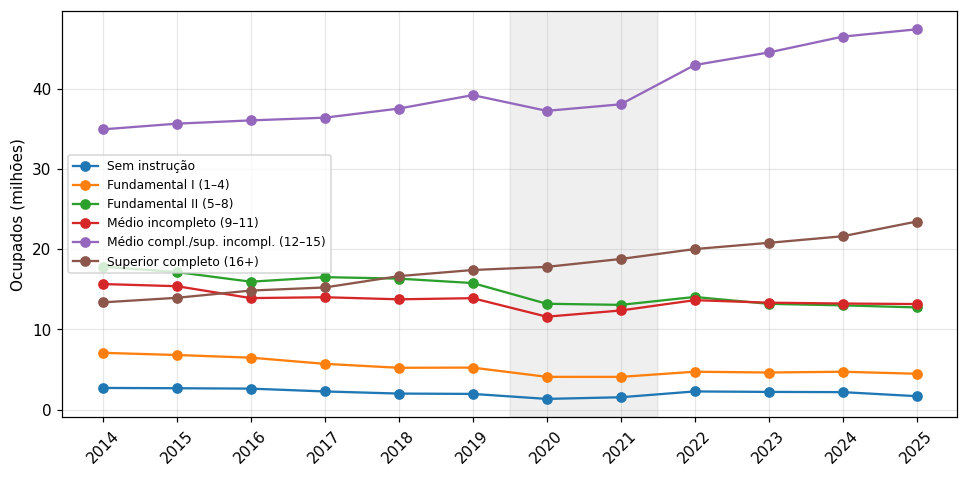

,Sem instrução,Fundamental I (1–4),Fundamental II (5–8),Médio incompleto (9–11),Médio compl./sup. incompl. (12–15),Superior completo (16+)
Ano,,,,,,
2014,2.69,7.08,17.83,15.66,34.98,13.38
2015,2.66,6.80,17.16,15.40,35.69,13.95
2016,2.61,6.47,15.96,13.91,36.10,14.85
2017,2.25,5.70,16.53,14.02,36.44,15.24
2018,1.99,5.21,16.34,13.76,37.57,16.65
2019,1.95,5.23,15.79,13.90,39.25,17.42
2020,1.32,4.08,13.20,11.59,37.29,17.81
2021,1.53,4.07,13.06,12.36,38.11,18.79
2022,2.26,4.72,14.05,13.65,43.01,20.03


In [6]:
anos_est = oc['VD3005'].astype(str).str.extract(r'(\d+)')[0].astype(float)
anos_est[oc['VD3005'].astype(str).str.startswith('Sem').values] = 0
nivel_educ = pd.cut(anos_est, bins=[-1, 0, 4, 8, 11, 15, 100],
                    labels=['Sem instrução', 'Fundamental I (1–4)', 'Fundamental II (5–8)',
                            'Médio incompleto (9–11)', 'Médio compl./sup. incompl. (12–15)',
                            'Superior completo (16+)'])
tab_educ = oc.groupby(['Ano', nivel_educ], observed=True)[w].sum().unstack() / 1e6
fig, ax = plt.subplots(figsize=(10.5, 4.8))
for c in tab_educ.columns:
    ax.plot(tab_educ.index, tab_educ[c], marker='o', label=c)
ax.set_ylabel('Ocupados (milhões)'); ax.legend(fontsize=8)
eixo_anos(ax, ANOS)
salva_fig('Figura_06_escolaridade')
guarda('Fig06_dados_escolaridade', tab_educ, 2)

### Figura 7 — Ocupados por cor ou raça

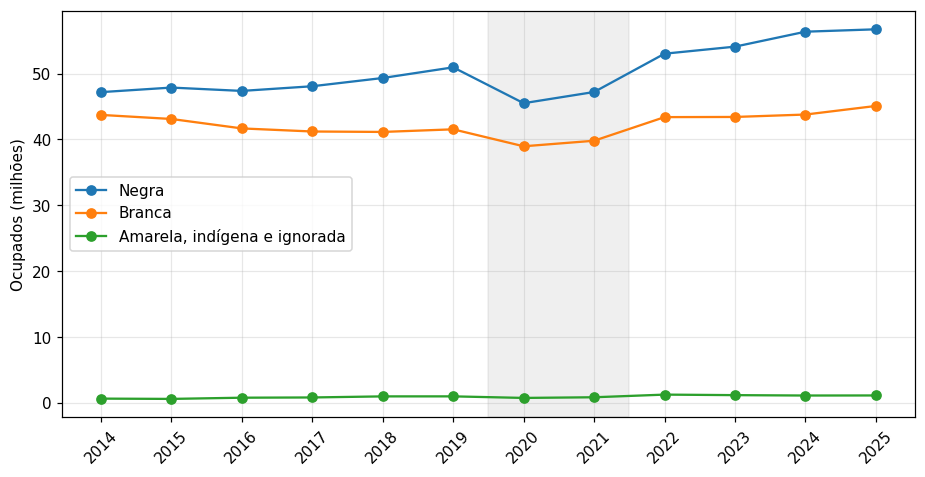

raca_neg,Amarela,Branca,Ignorado,Indígena,Negra
Ano,,,,,
2014,0.57,43.73,NaN,0.14,47.18
2015,0.50,43.11,NaN,0.17,47.87
2016,0.62,41.68,0.01,0.23,47.36
2017,0.62,41.21,0.01,0.26,48.07
2018,0.68,41.15,0.01,0.36,49.32
2019,0.69,41.54,0.02,0.35,50.94
2020,0.57,38.97,0.01,0.24,45.50
2021,0.63,39.81,0.02,0.27,47.20
2022,0.86,43.39,0.04,0.42,53.01


In [7]:
tab_raca = oc.groupby(['Ano', 'raca_neg'])[w].sum().unstack() / 1e6
fig, ax = plt.subplots(figsize=(10, 4.8))
for c in ['Negra', 'Branca']:
    ax.plot(tab_raca.index, tab_raca[c], marker='o', label=c)
outros = tab_raca.drop(columns=['Negra', 'Branca'], errors='ignore').sum(axis=1)
ax.plot(tab_raca.index, outros, marker='o', label='Amarela, indígena e ignorada')
ax.set_ylabel('Ocupados (milhões)'); ax.legend()
eixo_anos(ax, ANOS)
salva_fig('Figura_07_raca')
guarda('Fig07_dados_raca', tab_raca, 2)

### Figuras 8 e 9 — Formalidade por sexo e informalidade por cor ou raça

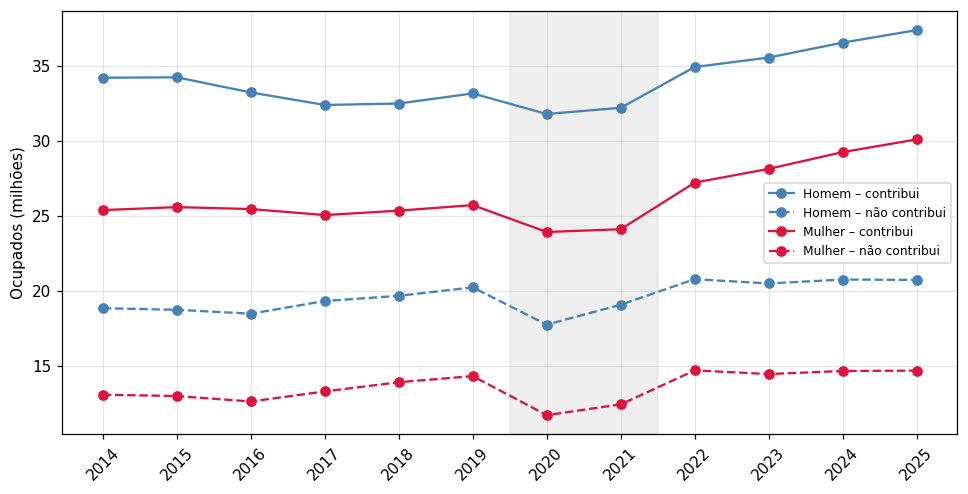

V2007     Homem                  Mulher              
form  Contribui Não contribui Contribui Não contribui
Ano                                                  
2014      34.22         18.87     25.41         13.12
2015      34.25         18.77     25.61         13.02
2016      33.24         18.51     25.48         12.66
2017      32.41         19.35     25.08         13.33
2018      32.51         19.70     25.37         13.94
2019      33.18         20.26     25.74         14.35
2020      31.81         17.78     23.95         11.75
2021      32.22         19.11     24.13         12.47
2022      34.94         20.81     27.24         14.73
2023      35.57         20.52     28.15         14.49
2024      36.56         20.78     29.27         14.69
2025      37.39         20.76     30.11         14.72

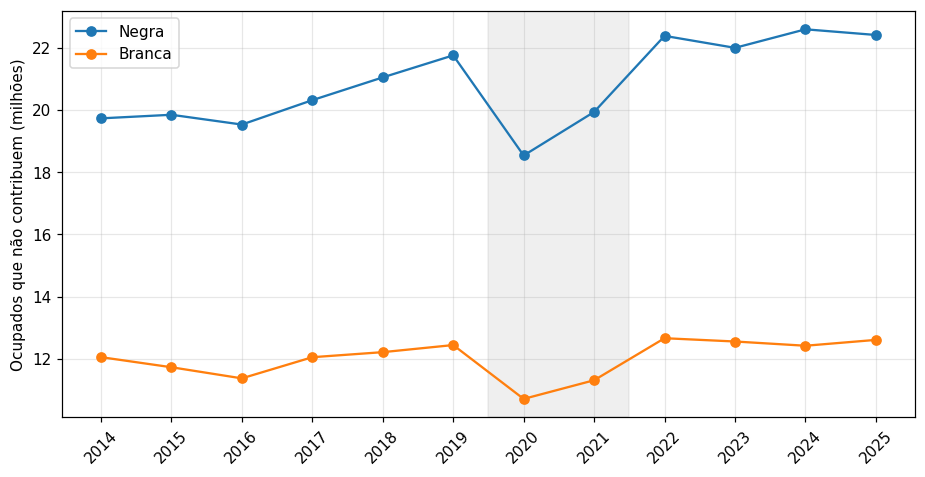

raca_neg,Amarela,Branca,Ignorado,Indígena,Negra
Ano,,,,,
2014,0.14,12.05,NaN,0.06,19.74
2015,0.13,11.72,NaN,0.08,19.86
2016,0.16,11.36,0.00,0.11,19.54
2017,0.19,12.04,0.00,0.12,20.33
2018,0.21,12.21,0.00,0.16,21.06
2019,0.23,12.44,0.01,0.17,21.77
2020,0.17,10.70,0.01,0.11,18.54
2021,0.19,11.30,0.01,0.13,19.95
2022,0.28,12.66,0.01,0.19,22.40


,informalidade homens (%),informalidade mulheres (%),informalidade negros (%),informalidade brancos (%)
Ano,,,,
2014,35.5,34.0,41.8,27.6
2019,37.9,35.8,42.7,29.9
2020,35.9,32.9,40.8,27.5
2025,35.7,32.8,39.6,28.0


In [8]:
tab_fs = (oc.assign(form=np.where(oc.formal_contrib, 'Contribui', 'Não contribui'))
            .groupby(['Ano', 'V2007', 'form'])[w].sum().unstack(['V2007', 'form']) / 1e6)
fig, ax = plt.subplots(figsize=(10.5, 5))
estilo = {('Homem', 'Contribui'): ('steelblue', '-'), ('Homem', 'Não contribui'): ('steelblue', '--'),
          ('Mulher', 'Contribui'): ('crimson', '-'), ('Mulher', 'Não contribui'): ('crimson', '--')}
for (s, f), (cor, ls) in estilo.items():
    ax.plot(tab_fs.index, tab_fs[(s, f)], marker='o', color=cor, ls=ls, label=f'{s} – {f.lower()}')
ax.set_ylabel('Ocupados (milhões)'); ax.legend(fontsize=8)
eixo_anos(ax, ANOS)
salva_fig('Figura_08_formalidade_sexo')
guarda('Fig08_dados_formalidade_sexo', tab_fs, 2)

inf = oc[~oc.formal_contrib]
tab_inf_raca = inf.groupby(['Ano', 'raca_neg'])[w].sum().unstack() / 1e6
fig, ax = plt.subplots(figsize=(10, 4.8))
for c in ['Negra', 'Branca']:
    ax.plot(tab_inf_raca.index, tab_inf_raca[c], marker='o', label=c)
ax.set_ylabel('Ocupados que não contribuem (milhões)'); ax.legend()
eixo_anos(ax, ANOS)
salva_fig('Figura_09_informais_raca')
guarda('Fig09_dados_informais_raca', tab_inf_raca, 2)

# Taxas citadas no texto (6.1.6)
taxas = pd.DataFrame({
    'informalidade homens (%)': oc.groupby('Ano').apply(lambda d: pct(d[~d.mulher], ~d[~d.mulher].formal_contrib), include_groups=False),
    'informalidade mulheres (%)': oc.groupby('Ano').apply(lambda d: pct(d[d.mulher], ~d[d.mulher].formal_contrib), include_groups=False),
    'informalidade negros (%)': oc.groupby('Ano').apply(lambda d: pct(d[d.negra], ~d[d.negra].formal_contrib), include_groups=False),
    'informalidade brancos (%)': oc.groupby('Ano').apply(lambda d: pct(d[d.branca], ~d[d.branca].formal_contrib), include_groups=False),
})
guarda('Apoio_6.1.6_taxas_informalidade', taxas.loc[[2014, 2019, 2020, 2025]])

## 6.2 A estrutura ocupacional por âncora e nível

### Tabela 7 — Perfil das âncoras, 2025

In [9]:
o25 = oc[(oc.Ano == 2025) & oc.ancora.notna()]
tab7 = o25.groupby('ancora').apply(lambda g: pd.Series({
    'Ocupados (milhões)': soma(g),
    'Idade média (anos)': np.average(g.V2009, weights=g[w]),
    'Mulheres (%)': pct(g, g.mulher),
    'Setor público (%)': pct(g, g.publico),
}), include_groups=False).sort_values('Ocupados (milhões)', ascending=False)
guarda('Tabela_07', tab7)

tab_nivel25 = (o25.groupby('nivel')[w].sum() / 1e6).to_frame('Ocupados (milhões)')
tab_nivel25['Participação (%)'] = 100 * tab_nivel25.iloc[:, 0] / tab_nivel25.iloc[:, 0].sum()
guarda('Apoio_6.2.1_niveis_2025', tab_nivel25.sort_values('Ocupados (milhões)', ascending=False), 2)

,Ocupados (milhões),Idade média (anos),Mulheres (%),Setor público (%)
ancora,,,,
"Comércio, Serviços e Lazer",31.4,39.4,56.0,3.8
"Indústria, Produção e Infraestrutura",18.0,39.3,9.3,2.1
Administração e Gestão,15.5,37.2,56.4,20.4
Cuidados,10.8,42.3,89.2,25.8
Agropecuária e Pesca,7.7,43.0,18.3,0.4
Transporte e Logística,7.5,40.4,6.2,5.1
Educação,3.6,43.5,69.8,65.9
Saúde,2.4,40.0,59.1,26.7
Segurança e Defesa,2.3,42.7,12.1,50.2


,Ocupados (milhões),Participação (%)
nivel,,
Básico/Operacional,75.90,73.71
Especialista,13.87,13.47
Técnico,9.24,8.97
Direção,3.96,3.85


### Apoio ao texto 6.2.2 — Dinâmicas por nível e por família (Administração, Indústria, C&I, Cuidados)

In [10]:
ORDEM_NIV = ['Direção', 'Especialista', 'Técnico', 'Básico/Operacional']

def por_nivel(ancora):
    t = oc[oc.ancora == ancora].groupby(['Ano', 'nivel'])[w].sum().unstack() / 1e6
    return t[[c for c in ORDEM_NIV if c in t.columns]]

def delta_familias(ancora, a0=2014, a1=2025, n=8):
    t = oc[oc.ancora == ancora].groupby(['Ano', 'nome_familia'])[w].sum().unstack() / 1e6
    d = (t.loc[a1] - t.loc[a0]).sort_values()
    return pd.concat([d.head(n), d.tail(n)]).to_frame(f'variação {a0}–{a1} (milhões)')

for anc in ['Administração e Gestão', 'Indústria, Produção e Infraestrutura', 'Ciência e Inovação', 'Cuidados']:
    print(f"\n==================== {anc} ====================")
    guarda(f'Apoio_niveis_{anc[:12]}', por_nivel(anc).loc[[2014, 2016, 2017, 2019, 2021, 2025]], 2)
    guarda(f'Apoio_familias_{anc[:12]}', delta_familias(anc), 2)

# Direção da Administração: queda 2014–2021 por família
print("\nAdministração e Gestão – Direção: variação 2014–2021 por família (milhões)")
dir_adm = oc[(oc.ancora == 'Administração e Gestão') & (oc.nivel == 'Direção')]
t = dir_adm.groupby(['Ano', 'nome_familia'])[w].sum().unstack() / 1e6
guarda('Apoio_direcao_adm_2014_2021', (t.loc[2021] - t.loc[2014]).sort_values().head(8).to_frame('variação (milhões)'), 2)


==================== Administração e Gestão ====================


nivel,Direção,Especialista,Técnico,Básico/Operacional
Ano,,,,
2014,2.77,1.80,1.68,7.48
2016,2.74,2.08,1.88,6.42
2017,2.53,2.13,1.73,6.63
2019,2.34,2.31,1.30,7.43
2021,1.61,2.54,1.48,7.10
2025,1.94,3.56,1.76,8.25


,variação 2014–2025 (milhões)
nome_familia,
Diretores gerais e gerentes gerais,-0.19
Dirigentes de vendas e comercialização,-0.18
Dirigentes financeiros,-0.17
Dirigentes de administração e de serviços não classificados anteriormente,-0.16
Dirigentes superiores da administração pública,-0.12
Trabalhadores de centrais de atendimento,-0.12
Trabalhadores de serviços de apoio à produção,-0.10
Caixas de banco e afins,-0.08
Analistas de gestão e administração,0.32



==================== Indústria, Produção e Infraestrutura ====================


nivel,Direção,Técnico,Básico/Operacional
Ano,,,
2014,0.31,2.31,14.96
2016,0.30,1.92,13.92
2017,0.29,1.72,13.69
2019,0.29,1.88,14.05
2021,0.22,1.92,13.44
2025,0.32,2.21,15.50


...


==================== Cuidados ====================


nivel,Direção,Especialista,Técnico,Básico/Operacional
Ano,,,,
2014,0.01,1.34,1.09,6.49
2016,0.01,1.48,1.49,6.51
2017,0.01,1.48,1.44,6.57
2019,0.02,1.62,1.55,6.63
2021,0.02,1.64,1.63,5.50
2025,0.01,2.41,1.77,6.63


,variação 2014–2025 (milhões)
nome_familia,
Trabalhadores dos serviços domésticos em geral,-0.73
Trabalhadores de cuidados pessoais em instituições,-0.17
Assistentes sociais,-0.03
Profissionais da medicina tradicional e alternativa,-0.00
Dirigentes de serviços de cuidado a pessoas idosas,0.00
Dirigentes de serviços de cuidados infantis,0.00
Profissionais de nível médio de partos,0.00
Acompanhantes e criados particulares,0.00
Profissionais de enfermagem,0.27



Administração e Gestão – Direção: variação 2014–2021 por família (milhões)


,variação (milhões)
nome_familia,
Dirigentes de vendas e comercialização,-0.25
Dirigentes de administração e de serviços não classificados anteriormente,-0.23
Diretores gerais e gerentes gerais,-0.22
Dirigentes financeiros,-0.19
Dirigentes superiores da administração pública,-0.14
Dirigentes de recursos humanos,-0.08
Dirigentes de políticas e planejamento,-0.04
Dirigentes de publicidade e relações públicas,-0.03


### Figura 10 — Cuidados por nível hierárquico

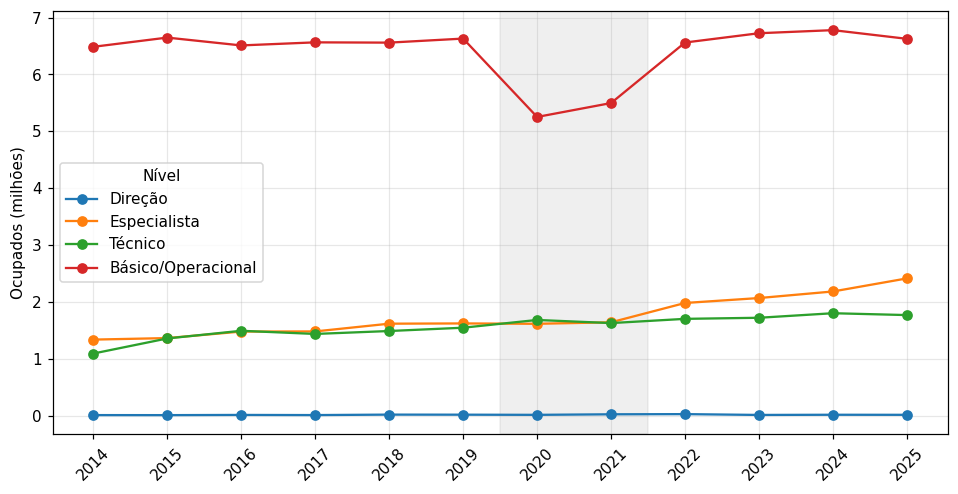

nivel,Direção,Especialista,Técnico,Básico/Operacional
Ano,,,,
2014,0.01,1.34,1.09,6.49
2015,0.01,1.36,1.36,6.65
2016,0.01,1.48,1.49,6.51
2017,0.01,1.48,1.44,6.57
2018,0.02,1.62,1.49,6.56
2019,0.02,1.62,1.55,6.63
2020,0.01,1.62,1.68,5.25
2021,0.02,1.64,1.63,5.50
2022,0.03,1.98,1.70,6.56


In [11]:
tab_cui_niv = por_nivel('Cuidados')
fig, ax = plt.subplots(figsize=(10.5, 5))
for c in tab_cui_niv.columns:
    ax.plot(tab_cui_niv.index, tab_cui_niv[c], marker='o', label=c)
ax.set_ylabel('Ocupados (milhões)'); ax.legend(title='Nível')
eixo_anos(ax, ANOS)
salva_fig('Figura_10_cuidados_nivel')
guarda('Fig10_dados_cuidados_nivel', tab_cui_niv, 2)

## 6.3 O cuidado

In [12]:
# Blocos da âncora Cuidados
ASSIST = ['1344', '2635', '3412']
def bloco_cuidado(cod, circ):
    if circ == 'saude':                      return 'Saúde'
    if circ == 'educacao' or cod == '1341':  return 'Educativo (infantil/especial)'
    if cod in ASSIST:                        return 'Assistência social'
    return 'Pessoal e doméstico'

fam_cui = cw[cw.ancora == 'Cuidados'][['cod_familia', 'nome_familia', 'nivel', 'circulo']].copy()
fam_cui['bloco'] = [bloco_cuidado(c, k) for c, k in zip(fam_cui.cod_familia, fam_cui.circulo)]
cui = oc[oc.ancora == 'Cuidados'].merge(fam_cui[['cod_familia', 'bloco']], on='cod_familia', how='left')
print("Famílias por bloco:", fam_cui.bloco.value_counts().to_dict(), "| registros sem bloco:", cui.bloco.isna().sum())

def perfil(d):
    t = d[w].sum()
    return pd.Series({
        'Ocupados (milhões)': t / 1e6,
        'Mulheres (%)': pct(d, d.mulher),
        'Mulheres negras (%)': pct(d, d.mulher & d.negra),
        'Contribui (%)': pct(d, d.formal_contrib),
        'Vínculo formal (%)': pct(d, d.formal_vinculo),
        'Setor público (%)': pct(d, d.publico),
        'Idade média': np.average(d.V2009, weights=d[w]),
        'Amostra (casos)': len(d),
    })

Famílias por bloco: {'Saúde': 10, 'Pessoal e doméstico': 8, 'Educativo (infantil/especial)': 4, 'Assistência social': 3} | registros sem bloco: 0


### Tabela 8 — Perfil dos blocos, 2014 e 2025

In [13]:
tab8 = cui[cui.Ano.isin([2014, 2025])].groupby(['bloco', 'Ano']).apply(perfil, include_groups=False)
guarda('Tabela_08', tab8)

Ocupados (milhões)  Mulheres (%)  \
bloco                         Ano                                      
Assistência social            2014                 0.2          79.3   
                              2025                 0.2          78.4   
Educativo (infantil/especial) 2014                 0.7          92.2   
                              2025                 1.5          90.8   
Pessoal e doméstico           2014                 6.4          94.3   
                              2025                 6.1          93.2   
Saúde                         2014                 1.7          79.1   
                              2025                 3.0          81.2   

                                    Mulheres negras (%)  Contribui (%)  \
bloco                         Ano                                        
Assistência social            2014                 36.9           89.6   
                              2025                 42.6           91.1   
Educativo (infantil/especial) 2014                 43.3           87.5   
                              2025                 49.5           86.9   
Pessoal e doméstico           2014                 59.1           44.0   
                              2025                 62.5           38.1   
Saúde                         2014                 34.8           92.7   
                              2025                 41.7           86.3   

                                    Vínculo formal (%)  Setor público (%)  \
bloco                         Ano                                           
Assistência social            2014                66.7               79.1   
                              2025                69.2               75.5   
Educativo (infantil/especial) 2014                75.5               62.8   
                              2025                71.9               68.9   
Pessoal e doméstico           2014                34.5                4.3   
                              2025                26.6                4.3   
Saúde                         2014                75.8               56.1   
                              2025                65.4               43.6   

                                    Idade média  Amostra (casos)  
bloco                         Ano                                 
Assistência social            2014         38.8            483.0  
                              2025         42.4            479.0  
Educativo (infantil/especial) 2014         37.2           1399.0  
                              2025         38.6           2619.0  
Pessoal e doméstico           2014         40.5          13704.0  
                              2025         44.2          11671.0  
Saúde                         2014         38.0           3706.0  
                              2025         40.3           5360.0

### Tabela 9 — Famílias do cuidado pessoal e doméstico

In [14]:
FAM_PD = {'9111': 'Domésticos em geral (9111)', '5311': 'Cuidadores de crianças (5311)',
          '5322': 'Cuidado pessoal a domicílio (5322)', '5321': 'Cuidado pessoal em instituições (5321)'}
pdom = cui[cui.V4010.isin(FAM_PD)]
serie_fam = pdom.groupby(['Ano', 'V4010'])[w].sum().unstack() / 1e6

linhas = {}
for cod, nome in FAM_PD.items():
    d = pdom[pdom.V4010 == cod]
    linhas[nome] = {
        'Ocupados 2014 (mi)': serie_fam.loc[2014, cod],
        'Ocupados 2025 (mi)': serie_fam.loc[2025, cod],
        'Contribui 2014 (%)': pct(d[d.Ano == 2014], d[d.Ano == 2014].formal_contrib),
        'Contribui 2025 (%)': pct(d[d.Ano == 2025], d[d.Ano == 2025].formal_contrib),
        'Vínculo formal 2014 (%)': pct(d[d.Ano == 2014], d[d.Ano == 2014].formal_vinculo),
        'Vínculo formal 2025 (%)': pct(d[d.Ano == 2025], d[d.Ano == 2025].formal_vinculo),
        'Choque 2020 (%)': 100 * (serie_fam.loc[2020, cod] / serie_fam.loc[2019, cod] - 1),
    }
guarda('Tabela_09', pd.DataFrame(linhas).T, 2)
print("Instituições + domicílio (5321+5322), milhões:",
      serie_fam[['5321', '5322']].sum(axis=1).loc[[2014, 2025]].round(2).to_dict())

,Ocupados 2014 (mi),Ocupados 2025 (mi),Contribui 2014 (%),Contribui 2025 (%),Vínculo formal 2014 (%),Vínculo formal 2025 (%),Choque 2020 (%)
Domésticos em geral (9111),4.83,4.10,41.30,35.50,31.77,23.97,-19.87
Cuidadores de crianças (5311),0.84,1.02,40.39,42.85,31.80,33.15,-24.45
Cuidado pessoal a domicílio (5322),0.36,0.74,46.20,34.79,31.61,20.29,-24.19
Cuidado pessoal em instituições (5321),0.27,0.10,92.72,90.54,86.24,82.19,-30.37


Instituições + domicílio (5321+5322), milhões: {2014: 0.62, 2025: 0.84}


### Tabela 10 — Composição por sexo e cor ou raça em cada nível

In [15]:
c2 = cui[cui.Ano.isin([2014, 2025]) & (cui.nivel != 'Direção')]
tab10 = (c2.groupby(['nivel', 'Ano', 'grupo'])[w].sum()
         / c2.groupby(['nivel', 'Ano'])[w].sum() * 100).unstack('grupo')
tab10 = tab10.drop(columns='Outros', errors='ignore')
tab10['Amostra (casos)'] = c2.groupby(['nivel', 'Ano']).size()
guarda('Tabela_10', tab10)
print("Casos no nível Direção:", cui[cui.nivel == 'Direção'].groupby('Ano').size().loc[[2014, 2025]].to_dict())

grupo                    Homens brancos  Homens negros  Mulheres brancas  \
nivel              Ano                                                     
Básico/Operacional 2014             2.2            3.7              35.0   
                   2025             2.5            4.9              30.1   
Especialista       2014             6.9            5.3              54.1   
                   2025             5.7            5.5              47.0   
Técnico            2014             9.5           14.0              34.2   
                   2025             8.7           13.0              31.0   

grupo                    Mulheres negras  Amostra (casos)  
nivel              Ano                                     
Básico/Operacional 2014             58.7            13913  
                   2025             61.5            12706  
Especialista       2014             32.8             2682  
                   2025             41.2             4088  
Técnico            2014             41.9             2679  
                   2025             46.2             3308

Casos no nível Direção: {2014: 18, 2025: 27}


### Tabela 11 — Renda: Cuidados e demais ocupações, por escolaridade (2023–2025)

In [16]:
b = oc[oc.Ano.between(2023, 2025) & oc.ancora.notna() & (oc.VD4016 > 0)].copy()
b['comparacao'] = np.where(b.ancora == 'Cuidados', 'Cuidados', 'Demais')
def renda_media(d):
    return np.average(d.VD4016, weights=d[w])

partes = []
for rotulo, filtro in [('todos', b), ('mulheres', b[b.mulher])]:
    t = filtro.groupby(['VD3004', 'comparacao']).apply(renda_media, include_groups=False).unstack()
    t['Dif. (%)'] = 100 * (t['Cuidados'] / t['Demais'] - 1)
    t.columns = [f'{c} – {rotulo}' for c in t.columns]
    partes.append(t)
guarda('Tabela_11', pd.concat(partes, axis=1), 0)

,Cuidados – todos,Demais – todos,Dif. (%) – todos,Cuidados – mulheres,Demais – mulheres,Dif. (%) – mulheres
VD3004,,,,,,
Sem instrução e menos de 1 ano de estudo,1181.0,1525.0,-23.0,1134.0,1394.0,-19.0
Fundamental incompleto ou equivalente,1155.0,1839.0,-37.0,1129.0,1403.0,-20.0
Fundamental completo ou equivalente,1325.0,2112.0,-37.0,1301.0,1626.0,-20.0
Médio incompleto ou equivalente,1165.0,1965.0,-41.0,1134.0,1523.0,-26.0
Médio completo ou equivalente,1783.0,2461.0,-28.0,1709.0,1959.0,-13.0
Superior incompleto ou equivalente,2101.0,2992.0,-30.0,1981.0,2334.0,-15.0
Superior completo,4056.0,6463.0,-37.0,3907.0,5165.0,-24.0


### Tabelas 12 e 13 — Cuidado de nível superior e Ciência e Inovação

In [17]:
sup = oc[oc.nivel.isin(['Especialista', 'Direção']) & oc.ancora.isin(['Cuidados', 'Ciência e Inovação'])].copy()
sup['periodo'] = np.select([sup.Ano.between(2014, 2016), sup.Ano.between(2024, 2025)],
                           ['2014–16', '2024–25'], default='fora')
sup = sup[sup.periodo != 'fora']

def perfil_periodo(d):
    s = perfil(d)
    s['Ocupados (milhões)'] = s['Ocupados (milhões)'] / d.Ano.nunique()   # média anual
    return s

tab12 = sup.groupby(['ancora', 'periodo']).apply(perfil_periodo, include_groups=False)
guarda('Tabela_12', tab12[['Ocupados (milhões)', 'Mulheres (%)', 'Mulheres negras (%)',
                           'Contribui (%)', 'Vínculo formal (%)', 'Setor público (%)']])

r = sup[sup.Ano.between(2023, 2025) & (sup.VD4016 > 0) & (sup.grupo != 'Outros')]
tab13 = r.groupby(['grupo', 'ancora']).apply(renda_media, include_groups=False).unstack('ancora')
tab13['Razão Cuidados / C&I'] = tab13['Cuidados'] / tab13['Ciência e Inovação']
guarda('Tabela_13', tab13, 2)

Ocupados (milhões)  Mulheres (%)  \
ancora             periodo                                     
Ciência e Inovação 2014–16                 1.2          24.1   
                   2024–25                 2.1          27.7   
Cuidados           2014–16                 1.4          89.2   
                   2024–25                 2.3          88.7   

                            Mulheres negras (%)  Contribui (%)  \
ancora             periodo                                       
Ciência e Inovação 2014–16                  4.8           91.5   
                   2024–25                  8.1           88.7   
Cuidados           2014–16                 33.1           89.4   
                   2024–25                 41.0           86.8   

                            Vínculo formal (%)  Setor público (%)  
ancora             periodo                                         
Ciência e Inovação 2014–16                71.0               16.2  
                   2024–25                65.4               10.7  
Cuidados           2014–16                69.6               53.4  
                   2024–25                62.6               49.0

ancora,Ciência e Inovação,Cuidados,Razão Cuidados / C&I
grupo,,,
Homens brancos,9926.97,5945.85,0.60
Homens negros,7804.55,4483.20,0.57
Mulheres brancas,7415.52,4703.09,0.63
Mulheres negras,5818.65,3820.65,0.66


### Tabela 14 — Cuidado ampliado (Cuidados + Saúde)

In [18]:
amp = oc[oc.ancora.isin(['Cuidados', 'Saúde'])]
tab14 = pd.DataFrame({
    'Cuidados (mi)': oc[oc.ancora == 'Cuidados'].groupby('Ano')[w].sum() / 1e6,
    'Saúde (mi)': oc[oc.ancora == 'Saúde'].groupby('Ano')[w].sum() / 1e6,
})
tab14['Ampliado (mi)'] = tab14.sum(axis=1)
tab14['% dos ocupados'] = 100 * tab14['Ampliado (mi)'] / ocup_ano
tab14['% mulheres'] = amp.groupby('Ano').apply(lambda d: pct(d, d.mulher), include_groups=False)
tab14['% mulheres negras'] = amp.groupby('Ano').apply(lambda d: pct(d, d.mulher & d.negra), include_groups=False)
guarda('Tabela_14', tab14.loc[[2014, 2019, 2020, 2025]])

,Cuidados (mi),Saúde (mi),Ampliado (mi),% dos ocupados,% mulheres,% mulheres negras
Ano,,,,,,
2014,8.9,1.4,10.3,11.2,85.5,47.5
2019,9.8,1.6,11.4,12.2,85.8,49.2
2020,8.6,1.6,10.2,11.9,84.4,46.9
2025,10.8,2.4,13.2,12.8,83.8,48.2


## 6.4 A plataformização do trabalho

Usa os microdados do módulo de plataformas digitais (2022 T4 e 2024 T3), com os códigos numéricos do IBGE, e os 200 pesos replicados para o erro-padrão.

In [19]:
import requests
PASTA_PNAD = pasta + 'pnad/'
brutos = {2024: pd.read_parquet(PASTA_PNAD + 'pnadc_plataformizacao_2024T3.parquet'),
          2022: pd.read_parquet(PASTA_PNAD + 'pnadc_plataformizacao_2022T4.parquet')}

# Deflator IPCA (nov/2022 -> ago/2024); se a API do IBGE falhar, usa o fator já calculado (1,0827)
try:
    def ipca(periodo):
        url = f'https://apisidra.ibge.gov.br/values/t/1737/n1/all/v/2266/p/{periodo}'
        return float(requests.get(url, timeout=30).json()[1]['V'])
    FATOR = ipca('202408') / ipca('202211')
except Exception:
    FATOR = 1.0827
DEFLATOR = {2024: 1.0, 2022: FATOR}
print(f"Fator IPCA 2022 -> 2024: {FATOR:.4f}")

def prep_plat(d, ano):
    d = d.copy()
    for c in ['UF', 'V2009', 'V2007', 'V2010', 'VD3004', 'VD4002', 'VD4009', 'VD4012', 'V4019',
              'VD4016', 'V4039', 'SD14001', 'S140091', 'S140092', 'S140093', 'S140094', 'V1028']:
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors='coerce')
    d = d[(d.V2009 >= 14) & (d.VD4002 == 1) & (~d.VD4009.isin([5, 6, 7])) & d.SD14001.notna()].copy()
    d['ano'] = ano
    d['cod'] = d.V4010.astype(str).str.zfill(4)
    d['plat'] = d.SD14001 == 1
    d['app_taxi'] = d.S140091 == 1
    d['app_transp'] = d.S140092 == 1
    d['app_entrega'] = (d.S140093 == 1) & d.plat
    d['app_servicos'] = d.S140094 == 1
    d['contribui'] = d.VD4012 == 1
    d['VD4016'] = d.VD4016 * DEFLATOR[ano]
    d['peso'] = d.V1028
    d['sexo'] = d.V2007.map({1: 'Homem', 2: 'Mulher'})
    d['faixa_idade'] = pd.cut(d.V2009, bins=[13, 24, 39, 59, 200], labels=['14–24', '25–39', '40–59', '60+'])
    d['raca'] = d.V2010.map({1: 'Branca', 2: 'Preta', 4: 'Parda', 3: 'Amarela/Indígena', 5: 'Amarela/Indígena'})
    d['instrucao'] = d.VD3004.map({1: '1 Sem instr./fund. incompl.', 2: '1 Sem instr./fund. incompl.',
                                   3: '2 Fund. compl./médio incompl.', 4: '2 Fund. compl./médio incompl.',
                                   5: '3 Médio compl./sup. incompl.', 6: '3 Médio compl./sup. incompl.',
                                   7: '4 Superior completo'})
    d = d.merge(cw[['cod_familia', 'ancora', 'nivel']], left_on='cod', right_on='cod_familia', how='left')
    return d

bases = {ano: prep_plat(d, ano) for ano, d in brutos.items()}
REPS = [c for c in bases[2024].columns if c.startswith('V1028') and len(c) == 8]
for ano in bases:
    bases[ano][REPS] = bases[ano][REPS].apply(pd.to_numeric, errors='coerce')
for ano, d in bases.items():
    print(f"{ano}: {len(d):,} ocupados no universo | {d.plat.sum():,} plataformizados na amostra | pesos replicados: {len(REPS)}")

Fator IPCA 2022 -> 2024: 1.0827
2024: 184,157 ocupados no universo | 2,743 plataformizados na amostra | pesos replicados: 200
2022: 178,163 ocupados no universo | 2,203 plataformizados na amostra | pesos replicados: 200


### Tabela 15 — Plataformizados por tipo de aplicativo

In [20]:
def por_tipo(d):
    p = d.peso
    return pd.Series({
        'Transporte particular de passageiros': p[d.app_transp].sum() / 1e3,
        'Entrega': p[d.app_entrega].sum() / 1e3,
        'Prestação de serviços': p[d.app_servicos].sum() / 1e3,
        'Táxi': p[d.app_taxi].sum() / 1e3,
        'Total de plataformizados': p[d.plat].sum() / 1e3,
        'Taxa de plataformização (%)': 100 * p[d.plat].sum() / p.sum(),
    })
tab15 = pd.DataFrame({ano: por_tipo(bases[ano]) for ano in [2022, 2024]})
tab15['Variação (%)'] = 100 * (tab15[2024] / tab15[2022] - 1)
tab15.loc['Taxa de plataformização (%)', 'Variação (%)'] = np.nan
guarda('Tabela_15', tab15)

,2022,2024,Variação (%)
Transporte particular de passageiros,679.5,877.9,29.2
Entrega,445.9,487.3,9.3
Prestação de serviços,193.0,293.6,52.1
Táxi,200.9,228.0,13.5
Total de plataformizados,1319.3,1653.8,25.4
Taxa de plataformização (%),1.5,1.9,NaN


### Tabela 16 — Perfil de plataformizados e não plataformizados

In [21]:
def composicao(d, var):
    out = {}
    for rot, m in [('Plataformizados', d.plat), ('Não plataformizados', ~d.plat)]:
        g = d[m]
        out[rot] = g.groupby(var, observed=True)['peso'].sum() / g.peso.sum() * 100
    return pd.DataFrame(out)

partes = []
for var in ['sexo', 'faixa_idade', 'raca', 'instrucao']:
    t = pd.concat({ano: composicao(bases[ano], var) for ano in [2022, 2024]}, axis=1)
    t.index = [f'{var}: {i}' for i in t.index]
    partes.append(t)
tab16 = pd.concat(partes)
tab16.columns = [f'{c[1]} {c[0]}' for c in tab16.columns]
guarda('Tabela_16', tab16)

taxa_sexo = {ano: bases[ano].groupby('sexo').apply(lambda g: 100 * g.peso[g.plat].sum() / g.peso.sum(), include_groups=False)
             for ano in [2022, 2024]}
print("Taxa de plataformização por sexo (%):", {a: t.round(1).to_dict() for a, t in taxa_sexo.items()})

,Plataformizados 2022,Não plataformizados 2022,Plataformizados 2024,Não plataformizados 2024
sexo: Homem,83.9,58.5,83.9,58.3
sexo: Mulher,16.1,41.5,16.1,41.7
faixa_idade: 14–24,10.2,15.8,11.1,15.3
faixa_idade: 25–39,47.5,38.8,47.3,37.6
faixa_idade: 40–59,36.4,37.9,36.2,38.9
faixa_idade: 60+,6.0,7.5,5.3,8.2
raca: Amarela/Indígena,0.9,1.2,0.9,1.1
raca: Branca,44.3,44.0,45.1,43.0
raca: Parda,42.6,43.4,41.1,44.2
raca: Preta,12.2,11.4,12.7,11.7


Taxa de plataformização por sexo (%): {2022: {'Homem': 2.2, 'Mulher': 0.6}, 2024: {'Homem': 2.7, 'Mulher': 0.7}}


### Tabela 17 — Prêmio de rendimento-hora (razão de totais)

In [22]:
def renda_hora(g):
    g = g[g.VD4016.notna() & (g.V4039 > 0)]
    return (g.VD4016 * g.peso).sum() / (g.V4039 * 4.33 * g.peso).sum()

def premio(d):
    return d.groupby('instrucao').apply(lambda g: 100 * (renda_hora(g[g.plat]) / renda_hora(g[~g.plat]) - 1),
                                        include_groups=False)

tab17 = pd.DataFrame({
    'Todos 2022': premio(bases[2022]), 'Todos 2024': premio(bases[2024]),
    'Só homens 2022': premio(bases[2022][bases[2022].sexo == 'Homem']),
    'Só homens 2024': premio(bases[2024][bases[2024].sexo == 'Homem']),
})
guarda('Tabela_17', tab17)

# Apoio ao texto: prêmio na renda mensal e jornadas
def premio_mensal(d):
    return d.groupby('instrucao').apply(lambda g: 100 * (np.average(g[g.plat].VD4016.dropna(), weights=g[g.plat].peso[g[g.plat].VD4016.notna()])
                                                        / np.average(g[~g.plat].VD4016.dropna(), weights=g[~g.plat].peso[g[~g.plat].VD4016.notna()]) - 1),
                                        include_groups=False)
print("Prêmio na renda mensal, 2024 (%):", premio_mensal(bases[2024]).round(1).to_dict())
b24 = bases[2024]
for rot, m in [('plataformizados', b24.plat), ('não plataformizados', ~b24.plat)]:
    g = b24[m & b24.V4039.notna()]
    print(f"Horas semanais, {rot}: {np.average(g.V4039, weights=g.peso):.1f}")

,Todos 2022,Todos 2024,Só homens 2022,Só homens 2024
instrucao,,,,
1 Sem instr./fund. incompl.,12.5,27.0,-0.3,18.1
2 Fund. compl./médio incompl.,14.8,27.1,9.7,19.7
3 Médio compl./sup. incompl.,3.6,2.1,-11.0,-9.3
4 Superior completo,-24.9,-34.9,-37.6,-45.0


Prêmio na renda mensal, 2024 (%): {'1 Sem instr./fund. incompl.': 47.4, '2 Fund. compl./médio incompl.': 49.9, '3 Médio compl./sup. incompl.': 14.8, '4 Superior completo': -29.8}
Horas semanais, plataformizados: 44.8
Horas semanais, não plataformizados: 39.3


### Tabela 18 — Plataformização por âncora (com erro-padrão pelos pesos replicados)

In [23]:
def indicadores(d, chaves):
    linhas = []
    for k, g in d.groupby(chaves, observed=True):
        pl, npl = g[g.plat], g[~g.plat]
        taxa = 100 * pl.peso.sum() / g.peso.sum()
        reps = 100 * pl[REPS].sum().to_numpy() / g[REPS].sum().to_numpy()
        ep = np.std(reps, ddof=1)
        linha = dict(zip(chaves, k if isinstance(k, tuple) else (k,)))
        linha.update({
            'n plat': len(pl), 'plat (mil)': pl.peso.sum() / 1e3, 'taxa (%)': taxa, 'EP': ep,
            'CV (%)': 100 * ep / taxa if taxa > 0 else np.nan,
            'renda-hora plat (R$)': renda_hora(pl) if len(pl) else np.nan,
            'renda-hora não plat (R$)': renda_hora(npl),
            'contribui plat (%)': 100 * np.average(pl.contribui, weights=pl.peso) if len(pl) else np.nan,
            'contribui não plat (%)': 100 * np.average(npl.contribui, weights=npl.peso),
        })
        linhas.append(linha)
    out = pd.DataFrame(linhas)
    out['confiabilidade'] = np.select(
        [out['n plat'] == 0, (out['n plat'] < 30) | (out['CV (%)'] > 30), out['CV (%)'] > 15],
        ['sem casos', 'não publicar', 'cautela'], default='boa')
    return out.sort_values('plat (mil)', ascending=False)

ind = {ano: indicadores(bases[ano], ['ancora']) for ano in [2022, 2024]}
tab18 = ind[2024].set_index('ancora').join(ind[2022].set_index('ancora')[['taxa (%)', 'EP', 'confiabilidade']],
                                           rsuffix=' 2022')
tab18['parcela dos plataformizados (%)'] = 100 * tab18['plat (mil)'] / tab18['plat (mil)'].sum()
guarda('Tabela_18', tab18, 2)

# Significância da variação 2022–2024 (diferença / erro combinado)
sig = (tab18['taxa (%)'] - tab18['taxa (%) 2022']) / np.sqrt(tab18['EP'] ** 2 + tab18['EP 2022'] ** 2)
print("Diferença 2024–2022 em múltiplos do erro combinado:", sig.round(1).dropna().to_dict())
total = indicadores(bases[2024].assign(total='Brasil'), ['total'])
print("Brasil 2024 – taxa, EP e CV:", total[['taxa (%)', 'EP', 'CV (%)']].round(3).to_dict('records'))

,n plat,plat (mil),taxa (%),EP,CV (%),renda-hora plat (R$),renda-hora não plat (R$),contribui plat (%),contribui não plat (%),confiabilidade,taxa (%) 2022,EP 2022,confiabilidade 2022,parcela dos plataformizados (%)
ancora,,,,,,,,,,,,,,
Transporte e Logística,2030,1193.06,17.28,0.46,2.64,13.15,14.65,25.01,68.74,boa,14.84,0.48,boa,72.14
"Comércio, Serviços e Lazer",484,303.84,1.01,0.07,6.77,21.03,13.83,65.68,60.20,boa,0.83,0.07,boa,18.37
Administração e Gestão,63,48.65,0.42,0.08,18.70,31.63,25.37,73.68,86.34,cautela,0.21,0.05,cautela,2.94
"Indústria, Produção e Infraestrutura",69,47.34,0.27,0.04,14.72,19.12,14.54,51.12,59.31,boa,0.21,0.03,cautela,2.86
Cuidados,24,22.30,0.28,0.09,31.27,17.56,12.52,71.55,46.69,não publicar,0.18,0.06,não publicar,1.35
Humanidades e Cultura,36,18.36,1.55,0.35,22.87,16.04,25.59,37.42,56.36,cautela,0.99,0.31,não publicar,1.11
Ciência e Inovação,16,8.98,0.51,0.17,34.09,39.49,47.62,68.78,89.28,não publicar,0.69,0.26,não publicar,0.54
Educação,7,5.64,0.46,0.26,56.13,8.67,26.59,95.08,73.52,não publicar,0.58,0.22,não publicar,0.34
Saúde,12,5.00,0.32,0.13,38.99,24.81,42.80,39.01,79.02,não publicar,0.51,0.23,não publicar,0.30


Diferença 2024–2022 em múltiplos do erro combinado: {'Transporte e Logística': 3.7, 'Comércio, Serviços e Lazer': 1.8, 'Administração e Gestão': 2.3, 'Indústria, Produção e Infraestrutura': 1.1, 'Cuidados': 0.9, 'Humanidades e Cultura': 1.2, 'Ciência e Inovação': -0.6, 'Educação': -0.4, 'Saúde': -0.7, 'Agropecuária e Pesca': -0.7}
Brasil 2024 – taxa, EP e CV: [{'taxa (%)': 1.868, 'EP': 0.052, 'CV (%)': 2.775}]


### Tabela 19 — Âncoras e níveis fora do Básico; serviços fora do transporte

In [24]:
an_niv = indicadores(bases[2024], ['ancora', 'nivel'])
por_niv = an_niv.groupby('nivel')['plat (mil)'].sum()
print("Parcela dos plataformizados por nível, 2024 (%):", (100 * por_niv / por_niv.sum()).round(1).to_dict())
tab19 = an_niv[(an_niv.nivel != 'Básico/Operacional') & an_niv.confiabilidade.isin(['boa', 'cautela'])]
guarda('Tabela_19', tab19.set_index(['ancora', 'nivel'])[['plat (mil)', 'taxa (%)', 'CV (%)', 'confiabilidade',
                                                          'contribui plat (%)', 'contribui não plat (%)']], 2)

# Plataformizados fora do grupo de risco (transporte e entrega), por componente
FAM_APP = ['8321', '8322', '9621']
def servicos(d):
    s = d[d.plat & ~(d.cod.isin(FAM_APP) & (d.VD4009 == 9))]
    return pd.Series({'total (mil)': s.peso.sum() / 1e3,
                      'Básico (mil)': s.peso[s.nivel == 'Básico/Operacional'].sum() / 1e3,
                      'qualificados (mil)': s.peso[s.nivel != 'Básico/Operacional'].sum() / 1e3})
guarda('Apoio_6.4.5_servicos', pd.DataFrame({ano: servicos(bases[ano]) for ano in [2022, 2024]}), 0)

Parcela dos plataformizados por nível, 2024 (%): {'Básico/Operacional': 90.7, 'Direção': 2.0, 'Especialista': 5.0, 'Técnico': 2.3}


,,plat (mil),taxa (%),CV (%),confiabilidade,contribui plat (%),contribui não plat (%)
ancora,nivel,,,,,,
Administração e Gestão,Especialista,33.13,1.28,23.90,cautela,79.08,80.46
"Comércio, Serviços e Lazer",Direção,31.60,3.28,16.35,cautela,72.59,83.69
Humanidades e Cultura,Especialista,16.30,1.96,24.58,cautela,31.16,55.51


,2022,2024
total (mil),434.0,529.0
Básico (mil),333.0,376.0
qualificados (mil),101.0,153.0


### Tabela 20 e Figura 11 — Série histórica do grupo de risco, 2014–2025

,Motociclistas (8321),Motoristas (8322),Mensageiros e entregadores (9621),Grupo de risco (total),Plataformizados estimados,Penetração (%)
Ano,,,,,,
2014,239.0,500.0,4.0,744.0,0.0,0.0
2015,244.0,519.0,2.0,766.0,11.0,1.0
2016,286.0,606.0,5.0,897.0,142.0,16.0
2017,283.0,701.0,4.0,988.0,234.0,24.0
2018,299.0,964.0,5.0,1268.0,513.0,40.0
2019,324.0,1100.0,4.0,1429.0,674.0,47.0
2020,387.0,963.0,17.0,1368.0,613.0,45.0
2021,476.0,1018.0,10.0,1504.0,750.0,50.0
2022,452.0,1043.0,11.0,1505.0,751.0,50.0


Base pré-aplicativo (média 2014–2015): 755 mil


,2024,2022
no grupo e usa app (mil),1124.6,885.4
no grupo e não usa app (mil),797.7,757.4
cobertura (%),68.0,67.1
precisão (%),58.5,53.9


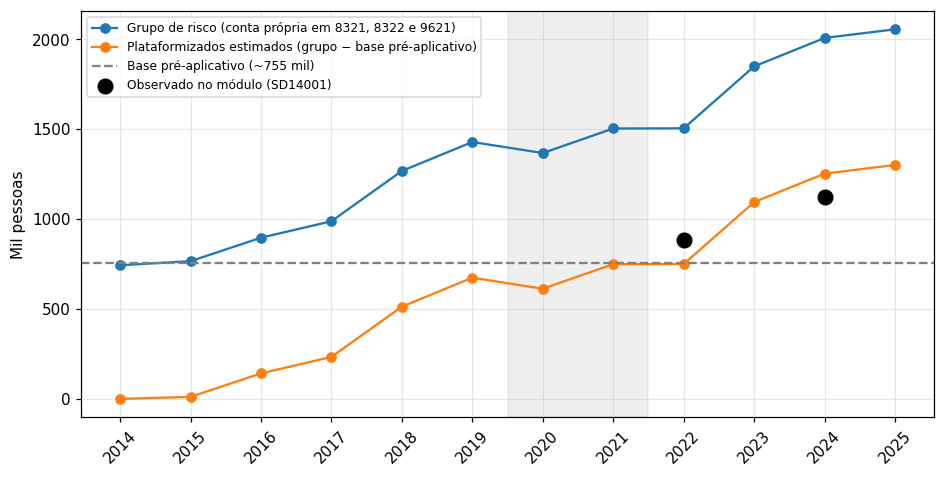

In [25]:
vd_oc = oc['VD4009'].astype(str).str.lower()
risco = oc[oc.V4010.isin(FAM_APP) & vd_oc.str.contains('conta')]
tab20 = risco.groupby(['Ano', 'V4010'])[w].sum().unstack().fillna(0) / 1e3
tab20.columns = [{'8321': 'Motociclistas (8321)', '8322': 'Motoristas (8322)',
                  '9621': 'Mensageiros e entregadores (9621)'}[c] for c in tab20.columns]
tab20['Grupo de risco (total)'] = tab20.sum(axis=1)
BASE_PRE_APP = tab20.loc[[2014, 2015], 'Grupo de risco (total)'].mean()
tab20['Plataformizados estimados'] = (tab20['Grupo de risco (total)'] - BASE_PRE_APP).clip(lower=0)
tab20['Penetração (%)'] = 100 * tab20['Plataformizados estimados'] / tab20['Grupo de risco (total)']
guarda('Tabela_20', tab20, 0)
print(f"Base pré-aplicativo (média 2014–2015): {BASE_PRE_APP:.0f} mil")

# Observado no módulo: plataformizados dentro do grupo de risco, e segmento sem aplicativo
obs = {}
for ano, d in bases.items():
    proxy = d.cod.isin(FAM_APP) & (d.VD4009 == 9)
    obs[ano] = {'no grupo e usa app (mil)': d.peso[proxy & d.plat].sum() / 1e3,
                'no grupo e não usa app (mil)': d.peso[proxy & ~d.plat].sum() / 1e3,
                'cobertura (%)': 100 * d.peso[proxy & d.plat].sum() / d.peso[d.plat].sum(),
                'precisão (%)': 100 * d.peso[proxy & d.plat].sum() / d.peso[proxy].sum()}
obs = pd.DataFrame(obs)
guarda('Apoio_6.4.6_modulo_grupo_risco', obs, 1)

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(tab20.index, tab20['Grupo de risco (total)'], marker='o', label='Grupo de risco (conta própria em 8321, 8322 e 9621)')
ax.plot(tab20.index, tab20['Plataformizados estimados'], marker='o', label='Plataformizados estimados (grupo − base pré-aplicativo)')
ax.axhline(BASE_PRE_APP, ls='--', color='grey', label=f'Base pré-aplicativo (~{BASE_PRE_APP:.0f} mil)')
ax.scatter(obs.columns, obs.loc['no grupo e usa app (mil)'], s=90, color='black', zorder=5,
           label='Observado no módulo (SD14001)')
ax.set_ylabel('Mil pessoas'); ax.legend(fontsize=8)
eixo_anos(ax, ANOS)
salva_fig('Figura_11_plataformizacao_serie')

## 6.5 Gênero e raça em Ciência e Inovação

In [26]:
def subarea(cod):
    if cod.startswith('25'):               return 'Tecnologia'
    if cod[:3] in ('214', '215', '216'):   return 'Engenharia'
    if cod[:3] in ('211', '213'):          return 'Ciências naturais'
    if cod[:3] == '212':                   return 'Matemática'
    if cod.startswith('1'):                return 'Gestão de C&I'
    return 'Outras C&I'

ci = oc[oc.ancora == 'Ciência e Inovação'].copy()
ci['subarea'] = ci.V4010.map(subarea)
PERIODOS = {2014: '2014–16', 2015: '2014–16', 2016: '2014–16', 2017: '2017–19', 2018: '2017–19',
            2019: '2017–19', 2022: '2022–23', 2023: '2022–23', 2024: '2024–25', 2025: '2024–25'}
ci['periodo'] = ci.Ano.map(PERIODOS)
print("Famílias por sub-área:", ci.groupby('subarea').V4010.nunique().to_dict())

def ind_genero(d):
    return pd.Series({'Ocupados (mil)': d[w].sum() / 1e3,
                      'Mulheres (%)': pct(d, d.mulher), 'Negros (%)': pct(d, d.negra),
                      'Mulheres negras (%)': pct(d, d.mulher & d.negra),
                      'Tipo RAIS (%)': pct(d, d.formal_vinculo),
                      'Setor público (%)': pct(d, d.publico), 'Amostra (casos)': len(d)})

def por_periodo(d):          # média anual do período
    return d.assign(**{w: d[w] / d.Ano.nunique()})

Famílias por sub-área: {'Ciências naturais': 7, 'Engenharia': 13, 'Gestão de C&I': 2, 'Matemática': 1, 'Tecnologia': 9}


### Tabela 21 e Figura 12 — Série anual de C&I

,Ocupados (mil),Mulheres (%),Negros (%),Mulheres negras (%),Tipo RAIS (%),Setor público (%),Amostra (casos),Mulheres – todos os ocupados (%)
Ano,,,,,,,,
2014,1157.9,24.8,17.9,3.8,74.2,16.6,1727.0,42.0
2015,1160.9,22.4,20.8,5.0,69.0,15.7,1754.0,42.2
2016,1136.2,25.0,20.2,5.6,69.8,16.3,1705.0,42.4
2017,1192.3,24.8,21.8,5.4,68.9,16.0,1795.0,42.6
2018,1259.3,26.4,25.0,5.6,67.7,15.1,1923.0,43.0
2019,1350.8,26.3,26.6,6.1,66.2,14.2,2051.0,42.9
2020,1350.1,26.4,26.2,6.4,66.0,14.8,1771.0,41.9
2021,1510.5,23.7,29.5,7.4,64.5,12.4,1650.0,41.6
2022,1816.4,28.1,29.3,7.2,63.9,11.2,2213.0,43.0


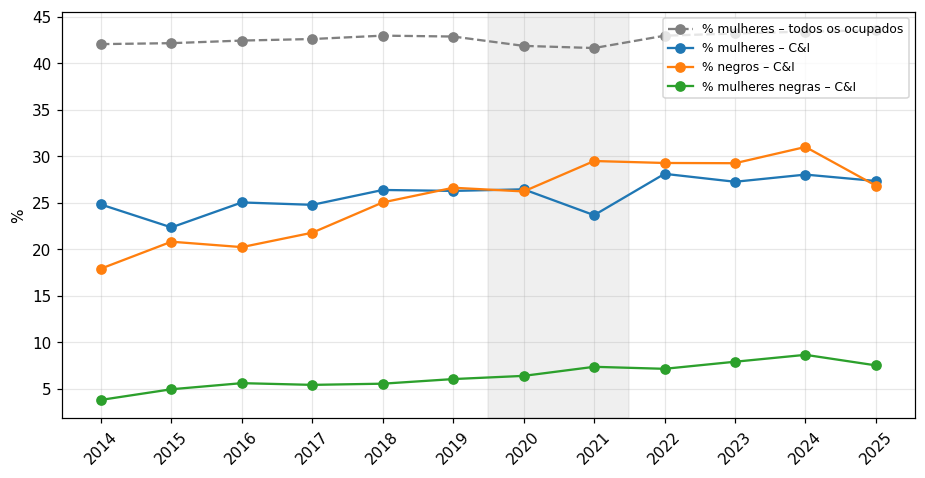

In [27]:
tab21 = ci.groupby('Ano').apply(ind_genero, include_groups=False)
tab21['Mulheres – todos os ocupados (%)'] = oc.groupby('Ano').apply(lambda d: pct(d, d.mulher), include_groups=False)
guarda('Tabela_21', tab21)

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(tab21.index, tab21['Mulheres – todos os ocupados (%)'], marker='o', ls='--', color='grey', label='% mulheres – todos os ocupados')
ax.plot(tab21.index, tab21['Mulheres (%)'], marker='o', label='% mulheres – C&I')
ax.plot(tab21.index, tab21['Negros (%)'], marker='o', label='% negros – C&I')
ax.plot(tab21.index, tab21['Mulheres negras (%)'], marker='o', label='% mulheres negras – C&I')
ax.set_ylabel('%'); ax.legend(fontsize=8)
eixo_anos(ax, ANOS)
salva_fig('Figura_12_CI_composicao')

### Tabelas 22, 23 e 24 — Sub-áreas, formalidade e setor público

In [28]:
base_p = ci.dropna(subset=['periodo'])
tab22 = (base_p.groupby(['subarea', 'periodo'])
               .apply(lambda d: ind_genero(por_periodo(d)), include_groups=False)
               [['Ocupados (mil)', 'Mulheres (%)', 'Negros (%)', 'Mulheres negras (%)', 'Amostra (casos)']]
               .unstack('periodo'))
guarda('Tabela_22', tab22)

base_f = ci[ci.periodo.isin(['2014–16', '2024–25'])]
tab23 = (base_f.groupby(['subarea', 'periodo'])
               .apply(lambda d: ind_genero(por_periodo(d))['Tipo RAIS (%)'], include_groups=False)
               .unstack('periodo'))
tab23['Variação (pontos)'] = tab23['2024–25'] - tab23['2014–16']
guarda('Tabela_23', tab23)

tab24 = (base_f[base_f.grupo != 'Outros'].groupby(['grupo', 'periodo'])
               .apply(lambda d: ind_genero(por_periodo(d))[['Ocupados (mil)', 'Tipo RAIS (%)', 'Setor público (%)']],
                      include_groups=False)
               .unstack('periodo'))
guarda('Tabela_24', tab24)

# Apoio ao texto: formalidade e setor público entre os que ENTRARAM em C&I no período
o0, o1 = tab24['Ocupados (mil)']['2014–16'], tab24['Ocupados (mil)']['2024–25']
f0, f1 = o0 * tab24['Tipo RAIS (%)']['2014–16'] / 100, o1 * tab24['Tipo RAIS (%)']['2024–25'] / 100
p0, p1 = o0 * tab24['Setor público (%)']['2014–16'] / 100, o1 * tab24['Setor público (%)']['2024–25'] / 100
entrantes = pd.DataFrame({'crescimento (mil)': o1 - o0,
                          '% formal entre os que entraram': 100 * (f1 - f0) / (o1 - o0),
                          '% do crescimento no setor público': 100 * (p1 - p0) / (o1 - o0)})
guarda('Apoio_6.5_entrantes', entrantes)

Ocupados (mil)                         Mulheres (%)          \
periodo                  2014–16 2017–19 2022–23 2024–25      2014–16 2017–19   
subarea                                                                         
Ciências naturais          145.9   141.0   178.5   235.3         37.1    43.6   
Engenharia                 550.2   598.3   820.9   891.6         22.8    24.0   
Gestão de C&I               93.0   118.8   149.3   146.1         29.0    32.6   
Matemática                   2.8     4.8    10.1    14.9         37.5    29.3   
Tecnologia                 359.7   404.5   698.6   782.8         19.4    20.4   

                                  Negros (%)                          \
periodo           2022–23 2024–25    2014–16 2017–19 2022–23 2024–25   
subarea                                                                
Ciências naturais    43.9    48.1       23.8    28.5    35.8    31.1   
Engenharia           31.1    29.7       17.2    23.0    27.1    27.8   
Gestão de C&I        21.2    26.9       18.1    19.5    28.9    26.9   
Matemática           26.9    33.9       20.7    11.7    12.5    28.0   
Tecnologia           20.9    19.3       22.1    27.2    30.4    29.8   

                  Mulheres negras (%)                         Amostra (casos)  \
periodo                       2014–16 2017–19 2022–23 2024–25         2014–16   
subarea                                                                         
Ciências naturais                 8.0    12.9    16.4    15.2           768.0   
Engenharia                        4.1     5.2     7.5     8.6          2527.0   
Gestão de C&I                     5.7     3.8     5.5     4.5           390.0   
Matemática                       13.4     2.7     8.3     9.2            17.0   
Tecnologia                        4.3     4.6     5.8     6.0          1484.0   

                                           
periodo           2017–19 2022–23 2024–25  
subarea                                    
Ciências naturais   823.0   563.0   750.0  
Engenharia         2806.0  2168.0  2579.0  
Gestão de C&I       478.0   304.0   352.0  
Matemática           25.0    23.0    32.0  
Tecnologia         1637.0  1645.0  1916.0

periodo,2014–16,2024–25,Variação (pontos)
subarea,,,
Ciências naturais,69.7,66.1,-3.5
Engenharia,66.1,54.4,-11.7
Gestão de C&I,71.0,75.9,4.9
Matemática,100.0,83.5,-16.5
Tecnologia,78.9,75.3,-3.5


Ocupados (mil)         Tipo RAIS (%)          \
periodo                 2014–16 2024–25       2014–16 2024–25   
grupo                                                           
Homens brancos            674.8  1032.3          70.3    66.0   
Homens negros             171.2   430.6          75.0    65.0   
Mulheres brancas          212.2   392.1          68.7    64.5   
Mulheres negras            55.3   167.5          76.1    62.3   

                 Setor público (%)          
periodo                    2014–16 2024–25  
grupo                                       
Homens brancos                13.8     9.2  
Homens negros                 19.6    11.1  
Mulheres brancas              19.1    12.7  
Mulheres negras               29.7    14.7

,crescimento (mil),% formal entre os que entraram,% do crescimento no setor público
grupo,,,
Homens brancos,357.5,58.0,0.4
Homens negros,259.5,58.5,5.6
Mulheres brancas,179.9,59.6,5.0
Mulheres negras,112.2,55.5,7.4


## Exportar todas as tabelas

In [29]:
with pd.ExcelWriter(OUT + 'capitulo6_tabelas.xlsx') as xw:
    for nome, t in TABELAS.items():
        t.to_excel(xw, sheet_name=nome[:31])
print(f"✓ {len(TABELAS)} tabelas em {OUT}capitulo6_tabelas.xlsx")
print("✓ figuras:", sorted(f for f in os.listdir(OUT) if f.endswith('.png')))

✓ 40 tabelas em /content/drive/MyDrive/Colab Notebooks/capitulo6/capitulo6_tabelas.xlsx
✓ figuras: ['Figura_03_ocupados.png', 'Figura_04_sexo.png', 'Figura_05_idade.png', 'Figura_06_escolaridade.png', 'Figura_07_raca.png', 'Figura_08_formalidade_sexo.png', 'Figura_09_informais_raca.png', 'Figura_10_cuidados_nivel.png', 'Figura_11_plataformizacao_serie.png', 'Figura_12_CI_composicao.png']
